## Figures S11C-D

In [1]:
from tkinter.filedialog import askdirectory
from tkinter import Tk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
os.environ["OUTDATED_IGNORE"] = "1"
from pathlib import Path
from itertools import compress
import datetime
import seaborn as sns
import pingouin as pg
from statsmodels.stats.multitest import multipletests
cur_dir = Path(os.getcwd())
src_dir = cur_dir.parent.parent
os.chdir(src_dir)
from functions.scale_bars import add_scalebar
from functions.date_range import date_range
from functions.photom_plots import plot_mean_sem
os.chdir(cur_dir)

#######################################
# Set these variables
ConditionsToPlot = ['fed','6pm-8am water dep']
colors = ['purple','darkblue']

# Select only trials beginning at a particular time
# Enter 'All' to include all trials, or number for trials starting at specific hour (in Zeitgeber time - lights on = 0)
TrialsBeginning = 'All'

# Set period to use as F0, for each condition
f0_period = {
              'fed': date_range(datetime.datetime(1,1,1,6,0),datetime.datetime(1,1,1,9,0), 1, 'seconds'),
             '6pm-8am water dep': date_range(datetime.datetime(1,1,1,6,0),datetime.datetime(1,1,1,9,0), 1, 'seconds')
             }

start_time = 6
end_date = 2
end_time = 5

MovingMeanVals = [30]
#######################################

ColorsToUse = colors[0:len(colors)]
plt.rcParams['figure.figsize'] = [9,10.5] # Make default figure size larger.
plt.rcParams['axes.xmargin'] = 0          # Make default margin on x axis zero.
plt.rcParams.update({'font.size': 16})

In [2]:
# Open a dialog box to select the directory to be analyzed
# (so that this code block can be run independently of the merging block above)
window = Tk()
window.wm_attributes('-topmost', 1)
window.withdraw()
Dir2 = askdirectory(parent = window)
os.chdir(Dir2 + '/')

# Load data
with open('AllTrialsData.pkl', 'rb') as f:
    AllTrials = pickle.load(f)

# Select trials with correct start time
if TrialsBeginning == 'All':
    UseTheseTrials = AllTrials['MouseTrialID']
else:
    # Select MouseTrialIDs that have a sample at this start time
    UseTheseTrials = list(compress(AllTrials['MouseTrialID'],AllTrials['dFF0'].loc[datetime.datetime(1,1,1,TrialsBeginning,0)].notnull()))
    # Now discard MouseTrialIDs that start before this time..
    if AllTrials['dFF0'].index[0] < datetime.datetime(1,1,1,TrialsBeginning,0):
        # Make a list of all the trials that have a time point 1h before desired start time
        NotTheseTrials = list(compress(AllTrials['MouseTrialID'],AllTrials['dFF0'].loc[datetime.datetime(1,1,1,TrialsBeginning-1,0)].notnull()))
        # Remove these trials
        UseTheseTrials = list(set(UseTheseTrials)-set(NotTheseTrials))
        del(NotTheseTrials)

In [3]:
# Recalculate dF/F0 and z-score

my_cols = pd.MultiIndex(levels = [[],[],[]], codes = [[],[],[]],
                            names = ['MouseID', 'MouseTrialID', 'Stim'])

AllTrials['dFF0'] = pd.DataFrame(columns=my_cols)
AllTrials['z-score'] = pd.DataFrame(columns=my_cols)

for cond in ConditionsToPlot:
    this_cond_trials = AllTrials['Raw_DS'].xs(cond, level=2, axis=1)
    f0 = this_cond_trials.loc[f0_period[cond]].mean()
    dff0 = (this_cond_trials - f0) / f0
    mn = dff0.loc[f0_period[cond]].mean()
    std = dff0.loc[f0_period[cond]].std()
    zs = (this_cond_trials - f0) / std

    dff0 = pd.concat([dff0], keys=[cond], names=['Stim'], axis=1)
    dff0 = dff0.reorder_levels(['MouseID', 'MouseTrialID', 'Stim'], axis=1)
    AllTrials['dFF0'] = pd.concat([AllTrials['dFF0'], dff0], axis=1)
    zs = pd.concat([zs], keys=[cond], names=['Stim'], axis=1)
    zs = zs.reorder_levels(['MouseID', 'MouseTrialID', 'Stim'], axis=1)
    AllTrials['z-score'] = pd.concat([AllTrials['z-score'], dff0], axis=1)

In [4]:
# Take moving means

Moving_Means = {}
# Loop through window sizes
for MM in MovingMeanVals:
    Moving_Means[MM] = {}
    # take moving mean with the given window size (assumes downsampling rate is the same for all trials)
    Moving_Means[MM]['dFF0'] = AllTrials['dFF0'].rolling(window = MM*60*AllTrials['DownSamplingRate'][0], center = False).mean()
    Moving_Means[MM]['z-score'] = pd.DataFrame(columns=my_cols)
    # then take z-score
    for cond in ConditionsToPlot:
        this_cond_trials = Moving_Means[MM]['dFF0'].xs(cond, level=2, axis=1)
        mn = this_cond_trials.loc[f0_period[cond]].mean()
        std = this_cond_trials.loc[f0_period[cond]].std()
        zs = (this_cond_trials - mn) / std
        zs = pd.concat([zs], keys=[cond], names=['Stim'], axis=1)
        zs = zs.reorder_levels(['MouseID', 'MouseTrialID', 'Stim'], axis=1)
        Moving_Means[MM]['z-score'] = pd.concat([Moving_Means[MM]['z-score'], zs], axis=1)

# Downstream analysis will be done on both moving mean and raw signals - therefore, also add raw data to this dataframe
Moving_Means['Raw'] = {}
Moving_Means['Raw']['dFF0'] = AllTrials['dFF0']
Moving_Means['Raw']['z-score'] = AllTrials['z-score']

In [5]:
# For each condition, calculate mean over trials for each mouse, then take grand mean over mice

# Initialize dicts. First level key = moving mean window size; second level key = signal (dFF0 or z-score).
Mouse_Means = {}
Mean_Over_Mice = {}
SEM_Over_Mice = {}

# Loop through moving mean values
my_cols = pd.MultiIndex(levels = [[],[]], codes = [[],[]],
                            names = [u'MouseTrialID',u'Stim'])
for MM in Moving_Means.keys():
    Mouse_Means[MM] = {'dFF0':pd.DataFrame(index = Moving_Means[MM]['dFF0'].index, columns = my_cols), 
                'z-score':pd.DataFrame(index = Moving_Means[MM]['z-score'].index, columns = my_cols)}
    Mean_Over_Mice[MM] = {'dFF0':pd.DataFrame(index = AllTrials['dFF0'].index),
                'z-score':pd.DataFrame(index = AllTrials['z-score'].index)}
    SEM_Over_Mice[MM] = {'dFF0':pd.DataFrame(index = AllTrials['dFF0'].index),
                'z-score':pd.DataFrame(index = AllTrials['z-score'].index)}
    # Loop through conditions
    for Stim in ConditionsToPlot:
        # Get trials for this condition
        ThisStimTrials_dFF0 = Moving_Means[MM]['dFF0'].xs(Stim, level=2, axis=1)
        ThisStimTrials_ZS = Moving_Means[MM]['z-score'].xs(Stim, level=2, axis=1)
        # Loop through mice for this condition
        for Mouse in list(set(ThisStimTrials_dFF0.columns.get_level_values('MouseID'))):
            # Take mean over trials for this mouse
            Mouse_Means[MM]['dFF0'] = pd.concat([Mouse_Means[MM]['dFF0'],
                                            pd.DataFrame(ThisStimTrials_dFF0.xs(Mouse, level=0, axis=1).mean(axis=1),
                                                        columns = pd.MultiIndex.from_arrays([[Mouse],[Stim]], names = ['MouseID', 'Stim']))
                                            ], axis=1)
            Mouse_Means[MM]['z-score'] = pd.concat([Mouse_Means[MM]['z-score'],
                                            pd.DataFrame(ThisStimTrials_ZS.xs(Mouse, level=0, axis=1).mean(axis=1),
                                                        columns = pd.MultiIndex.from_arrays([[Mouse],[Stim]], names = ['MouseID', 'Stim']))
                                            ], axis=1)
        # Take mean and SEM over mice for this condition
        Mean_Over_Mice[MM]['dFF0'][Stim] = Mouse_Means[MM]['dFF0'].xs(Stim, level=1, axis=1).mean(axis=1)
        SEM_Over_Mice[MM]['dFF0'][Stim] = Mouse_Means[MM]['dFF0'].xs(Stim, level=1, axis=1).sem(axis=1)
        Mean_Over_Mice[MM]['z-score'][Stim] = Mouse_Means[MM]['z-score'].xs(Stim, level=1, axis=1).mean(axis=1)
        SEM_Over_Mice[MM]['z-score'][Stim] = Mouse_Means[MM]['z-score'].xs(Stim, level=1, axis=1).sem(axis=1)

In [6]:
# Get event labels for each condition
EventLabels = pd.DataFrame()
for Stim in ConditionsToPlot:
    EventLabels[Stim] = AllTrials['Events'][[AllTrials['MouseTrialID'][i] for i in range(len(AllTrials['Condition'])) if AllTrials['Condition'][i] == Stim][0]]
# Remove labels at the time of lights-on and off - we don't need to add these to the plot
EventLabels = EventLabels.loc[[i.time() != datetime.time(12,0) for i in EventLabels.index]]
EventLabels = EventLabels.loc[[i.time() != datetime.time(0,0) for i in EventLabels.index]]

In [7]:
# Cut data
for MM in MovingMeanVals:
    for k in Mean_Over_Mice[MM].keys():
        Mean_Over_Mice[MM][k] = Mean_Over_Mice[MM][k].loc[date_range(datetime.datetime(1,1,1,start_time,0,0),
                                                                     datetime.datetime(1,1,end_date,end_time,0,0),
                                                                     1,'seconds')]
        SEM_Over_Mice[MM][k] = SEM_Over_Mice[MM][k].loc[date_range(datetime.datetime(1,1,1,start_time,0,0),
                                                                   datetime.datetime(1,1,end_date,end_time,0,0),
                                                                   1,'seconds')]

C:\Users\sjwal\AppData\Local\Temp\ipykernel_31628\2413615.py:22: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot([j,j],ylim)


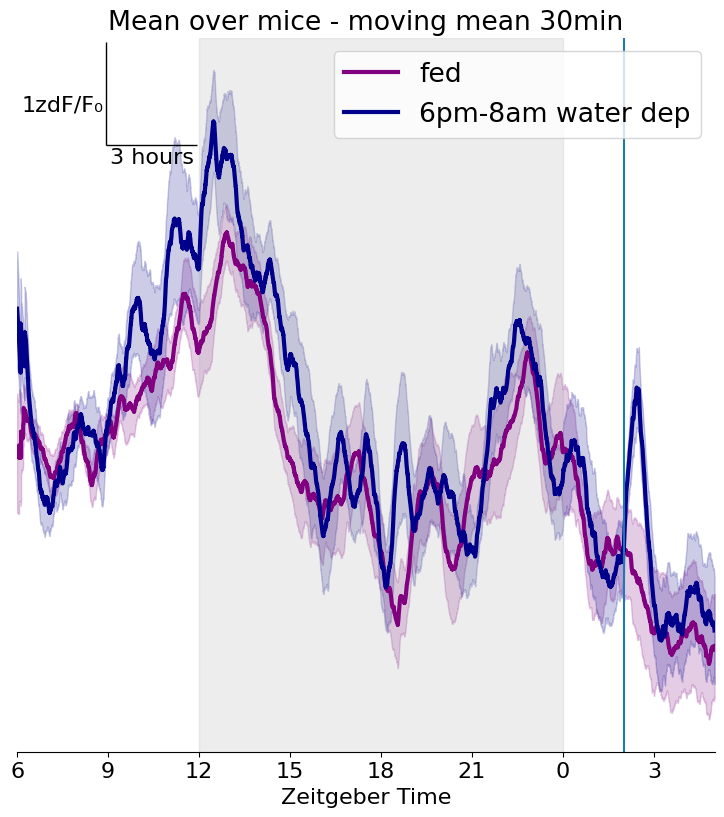

In [8]:
# Now plot different moving mean window values, dF/F0 and z-score in separate figures
for mm in MovingMeanVals:
    # Loop through dFF0/z-score
    signal = "z-score"
    fig, ax = plot_mean_sem(Mean_Over_Mice[mm][signal],
                            SEM_Over_Mice[mm][signal],
                            ConditionsToPlot,
                            ColorsToUse)
    ax.set(ylabel = signal, xlabel = 'Zeitgeber Time', title = 'Mean over mice - moving mean '+str(mm)+'min')
    if signal == 'dFF0':
            sizey = 0.01
            labely = u'1% dF/F\u2080'
    elif signal == 'z-score':
            sizey = 1
            labely = u'1zdF/F\u2080'
    _ = add_scalebar(ax, matchx=False, matchy=False, sizex=0.125, sizey=sizey, hidex=False, hidey=True,
                    labelx='3 hours', labely=labely, loc='upper left')
    
    ylim = ax.get_ylim()
    # Plot line to mark other events
    for j in list(EventLabels[EventLabels.notnull().any(axis=1)].index):
            ax.plot([j,j],ylim)
    
    ax.set(xlim=[Mean_Over_Mice[mm][signal].index[0],Mean_Over_Mice[mm][signal].index[-1]],
            xticks=date_range(datetime.datetime(1,1,1,6,0),datetime.datetime(1,1,2,3,0),3,'hours'),
            xticklabels=[6,9,12,15,18,21,0,3])

    # save figure as .pdf and .png
    figname = ("MM"+str(mm)+"mins_"+signal+"_"+ ', '.join(ConditionsToPlot))
#    plt.savefig(figname+".pdf")
#    plt.savefig(figname+".png")

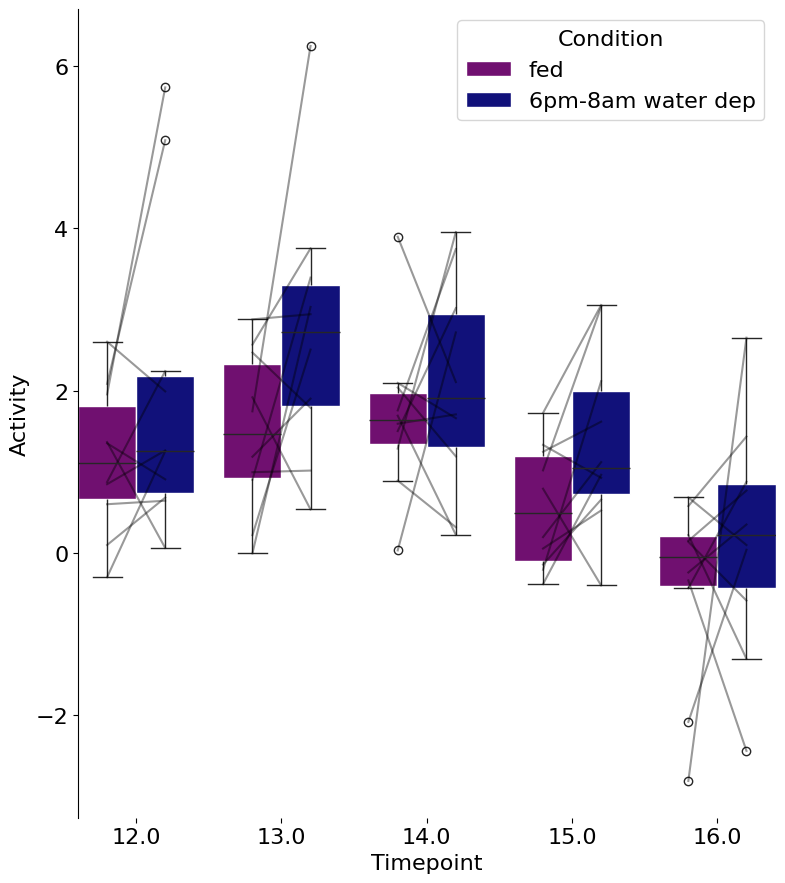

In [9]:
# Take average activity in 30min bins, instead of 1min mean at 30min intervals.
# Bin is from 29 mins before timepoint to timepoint (i.e. label is on right edge of bin).
binmins = 60 # interval between bins, in minutes
times = date_range(datetime.datetime(1,1,1,12,0,0),datetime.datetime(1,1,1,16,0,0),binmins,'minutes')

DataPoints_Bins = {}
MeanPoints_Bins = pd.DataFrame()

#ConditionsToPlot = ['fed', '6pm-8am fast']
#ColorsToUse = ['purple', 'green']

for Stim in ConditionsToPlot:
    DataPoints_Bins[Stim] = pd.DataFrame()
    for timepoint in times:
        this_time = timepoint.hour + timepoint.minute/60
        DataPoints_Bins[Stim][this_time] = Mouse_Means[30]['z-score'].xs(Stim,level=1,axis=1).loc[date_range(timepoint-datetime.timedelta(minutes=binmins-1),timepoint,1,'seconds')].mean()

# Dataframe with factors and datapoints
comp = pd.DataFrame({'Condition':[],
       'Mouse':[],
       'Timepoint':[],
       'Activity':[]})
for Stim in ConditionsToPlot:
    for Mouse in DataPoints_Bins[Stim].index:
        for timepoint in DataPoints_Bins[Stim].columns:
            comp.loc[len(comp.index)] = [Stim, Mouse, timepoint, 
                    DataPoints_Bins[Stim][timepoint][Mouse]]

# Plot as boxplot
fig, ax = plt.subplots(1,1)
PROPS = {
    'boxprops':{'edgecolor':'w'},
}
_ = sns.boxplot(x='Timepoint', y='Activity', hue='Condition', data=comp, palette = ColorsToUse, ax=ax, **PROPS)

# Remove frame
for pos in ['right', 'top', 'bottom']:
    ax.spines[pos].set_visible(False)

# add connecting lines
TimePointComparison_Bins = {}
num_conds = len(ConditionsToPlot)
for i,timepoint in enumerate(DataPoints_Bins[Stim].columns):
    TimePointComparison_Bins[timepoint]=pd.DataFrame()
    for Stim in ConditionsToPlot:
        TimePointComparison_Bins[timepoint][Stim] = DataPoints_Bins[Stim][timepoint]
    
    _ = plt.plot([ax.get_xticks()[i]-0.2,ax.get_xticks()[i]+0.2],
#        [a-b for a,b in zip([ax.get_xticks()[i]]*num_conds, np.linspace(-0.3,0.3,num_conds))][::-1], 
                 TimePointComparison_Bins[timepoint].transpose(),
                 color='black', alpha=0.4)

#plt.savefig('FoodRemoval_BoxPlot_'+str(binmins)+'min-bins.png')
#plt.savefig('FoodRemoval_BoxPlot_'+str(binmins)+'min-bins.pdf')

In [10]:
# Statistical test: two-way repeated measures ANOVA
pg.rm_anova(dv='Activity', within=['Timepoint', 'Condition'], subject='Mouse', 
                  data=comp, detailed=True)

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,Timepoint,62.879907,4,36,15.719977,16.249443,1.085555e-07,0.000100,0.305601,0.494948
1,Condition,14.823979,1,9,14.823979,3.704333,8.640834e-02,0.086408,0.094000,1.000000
2,Timepoint * Condition,1.937473,4,36,0.484368,0.591379,6.710487e-01,0.567272,0.013379,0.511064


In [11]:
# Post-hoc paired t-test for binned data (if 2 conditions)

TimePointComparison_Bins_res = pd.DataFrame()
for timepoint in DataPoints_Bins[Stim].columns:
    with np.errstate(divide='ignore', invalid='ignore'):    #ignore runtime errors from Pingouin
        app = pg.ttest(TimePointComparison_Bins[timepoint][ConditionsToPlot[0]],
                        TimePointComparison_Bins[timepoint][ConditionsToPlot[1]],
                        paired=True)
    app.index = [timepoint]
    TimePointComparison_Bins_res = pd.concat([TimePointComparison_Bins_res,app],axis=0)

# These p-values are uncorrected. Correct using Holm-Sidak method
mc = multipletests(pvals=TimePointComparison_Bins_res['p-val'].values,
                   alpha=0.05,
                   method='holm-sidak')
TimePointComparison_Bins_res['p_corrected'] = mc[1]
TimePointComparison_Bins_res['significance'] = mc[0]

#all_res['t-test'] = TimePointComparison_Bins_res['p_corrected'].copy()
TimePointComparison_Bins_res

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power,p_corrected,significance
12.0,-1.646260,9,two-sided,0.134117,"[-1.99, 0.31]",0.558748,0.857,0.352147,0.350802,False
13.0,-2.111106,9,two-sided,0.063955,"[-2.54, 0.09]",0.915026,1.465,0.731164,0.232308,False
14.0,-0.721560,9,two-sided,0.488886,"[-1.6, 0.82]",0.334106,0.384,0.157390,0.637636,False
15.0,-2.381588,9,two-sided,0.041121,"[-1.56, -0.04]",0.845244,2.045,0.663437,0.189375,False
16.0,-0.887251,9,two-sided,0.398033,"[-2.14, 0.93]",0.466715,0.428,0.261969,0.637636,False
